In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#444444", "axes.labelcolor": "#222222",
    "text.color": "#222222", "xtick.color": "#222222", "ytick.color": "#222222",
    "font.size": 11, "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": "#e0e0e0", "grid.linewidth": 0.6,
})
TEAL, CORAL, NAVY, GOLD, GREY = "#1f7a72", "#e2725b", "#2c3e5c", "#d4a017", "#888888"
SECTOR_COLORS = {
    "Technology": "#1f7a72", "Financials": "#2c3e5c", "Healthcare": "#e2725b",
    "Energy": "#d4a017", "Consumer Staples": "#7a8c63", "Communication Services": "#a65d8a",
}
RISK_FREE_RATE = 0.015  # approx. average 3-month T-bill yield, 2013-2018


C:\Users\tanga\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df = pd.read_csv("portfolio_stocks.txt")
df.to_csv("portfolio_stocks.csv")
df["date"] = pd.to_datetime(df["date"])
benchmark = pd.read_csv("market_benchmark.txt")
df.to_csv("market_benchmark.csv")
benchmark["date"] = pd.to_datetime(benchmark["date"])

print(f"Portfolio data shape: {df.shape}")
print(f"Tickers: {sorted(df['Name'].unique())}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
df.head()

Portfolio data shape: (10072, 8)
Tickers: ['AAPL', 'DIS', 'JNJ', 'JPM', 'MSFT', 'NVDA', 'WMT', 'XOM']
Date range: 2013-02-08 to 2018-02-07


,date,open,high,low,close,volume,Name,Sector
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL,Technology
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL,Technology
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL,Technology
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL,Technology
4,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL,Technology


## Data Cleaning

In [3]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"Trading days per ticker:")
print(df.groupby('Name').size())

Missing values per column:
date      0
open      0
high      0
low       0
close     0
volume    0
Name      0
Sector    0
dtype: int64

Duplicate rows: 0
Trading days per ticker:
Name
AAPL    1259
DIS     1259
JNJ     1259
JPM     1259
MSFT    1259
NVDA    1259
WMT     1259
XOM     1259
dtype: int64


In [4]:
tickers = sorted(df["Name"].unique())
sector_map = df.drop_duplicates("Name").set_index("Name")["Sector"].to_dict()

# Wide price matrix: rows = date, columns = ticker
prices = df.pivot(index="date", columns="Name", values="close").sort_index()

# Daily simple returns
returns = prices.pct_change().dropna()

# Equal-weighted portfolio daily return (rebalanced daily)
portfolio_returns = returns.mean(axis=1)

# Align benchmark to the same trading days
bench = benchmark.set_index("date")["benchmark_return"].reindex(returns.index)

print(f"Price matrix shape: {prices.shape}")
print(f"Trading days with valid returns: {len(returns)}")
prices.head()

Price matrix shape: (1259, 8)
Trading days with valid returns: 1258


Name,AAPL,DIS,JNJ,JPM,MSFT,NVDA,WMT,XOM
date,,,,,,,,
2013-02-08,67.8542,54.66,75.48,48.63,27.55,12.37,71.48,88.61
2013-02-11,68.5614,54.75,75.41,48.66,27.86,12.51,71.40,88.28
2013-02-12,66.8428,54.95,75.80,49.14,27.88,12.43,71.40,88.46
2013-02-13,66.7156,54.96,75.66,48.68,28.03,12.37,71.39,88.67
2013-02-14,66.6556,54.88,75.81,49.22,28.04,12.73,70.82,88.52


## Price trend analysis

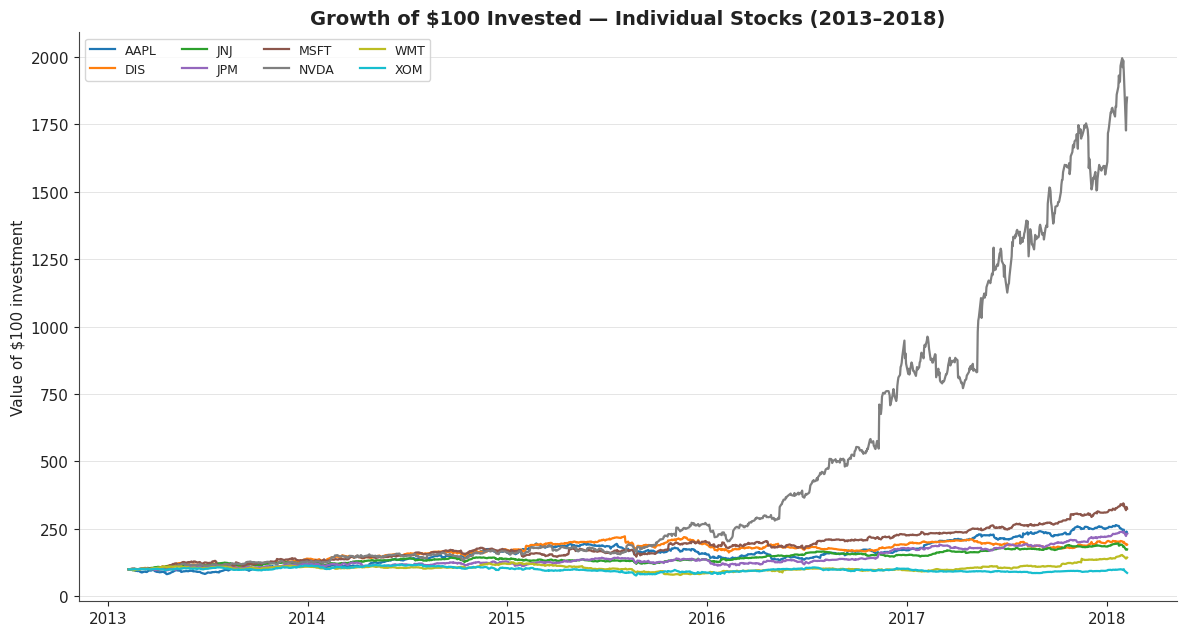

In [5]:
normalized = prices / prices.iloc[0] * 100

fig, ax = plt.subplots(figsize=(12, 6.5))
colors = plt.cm.tab10(np.linspace(0, 1, len(tickers)))
for i, t in enumerate(tickers):
    ax.plot(normalized.index, normalized[t], label=t, linewidth=1.6, color=colors[i])
ax.set_title("Growth of $100 Invested — Individual Stocks (2013–2018)")
ax.set_ylabel("Value of $100 investment")
ax.legend(ncol=4, fontsize=9, loc="upper left")
ax.grid(axis="y")
plt.tight_layout()
plt.show()

## Technical Analysis - Moving avgs.

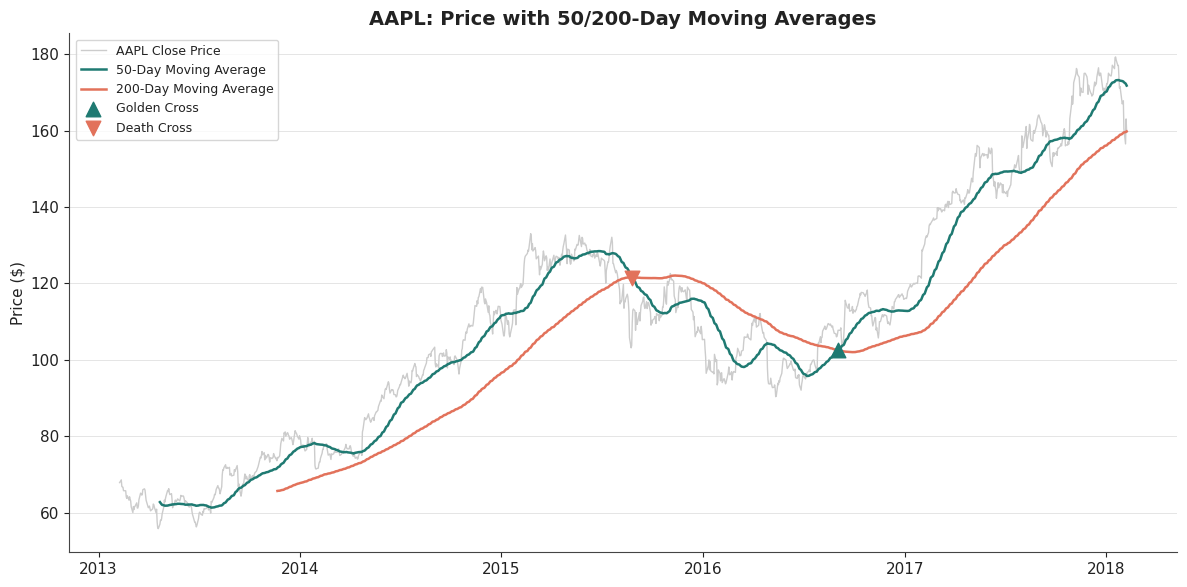

In [6]:
highlight = "AAPL"
hl_prices = prices[highlight].dropna()
ma50 = hl_prices.rolling(50).mean()
ma200 = hl_prices.rolling(200).mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(hl_prices.index, hl_prices.values, color="#cccccc", linewidth=1, label=f"{highlight} Close Price")
ax.plot(ma50.index, ma50.values, color=TEAL, linewidth=1.8, label="50-Day Moving Average")
ax.plot(ma200.index, ma200.values, color=CORAL, linewidth=1.8, label="200-Day Moving Average")

diff = ma50 - ma200
cross = np.sign(diff).diff().fillna(0)
golden = hl_prices.index[(cross > 0) & diff.notna()]
death = hl_prices.index[(cross < 0) & diff.notna()]
ax.scatter(golden, ma50.loc[golden], marker="^", color=TEAL, s=110, zorder=5, label="Golden Cross")
ax.scatter(death, ma50.loc[death], marker="v", color=CORAL, s=110, zorder=5, label="Death Cross")

ax.set_title(f"{highlight}: Price with 50/200-Day Moving Averages")
ax.set_ylabel("Price ($)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(axis="y")
plt.tight_layout()
plt.show()

## Volatility Analysis

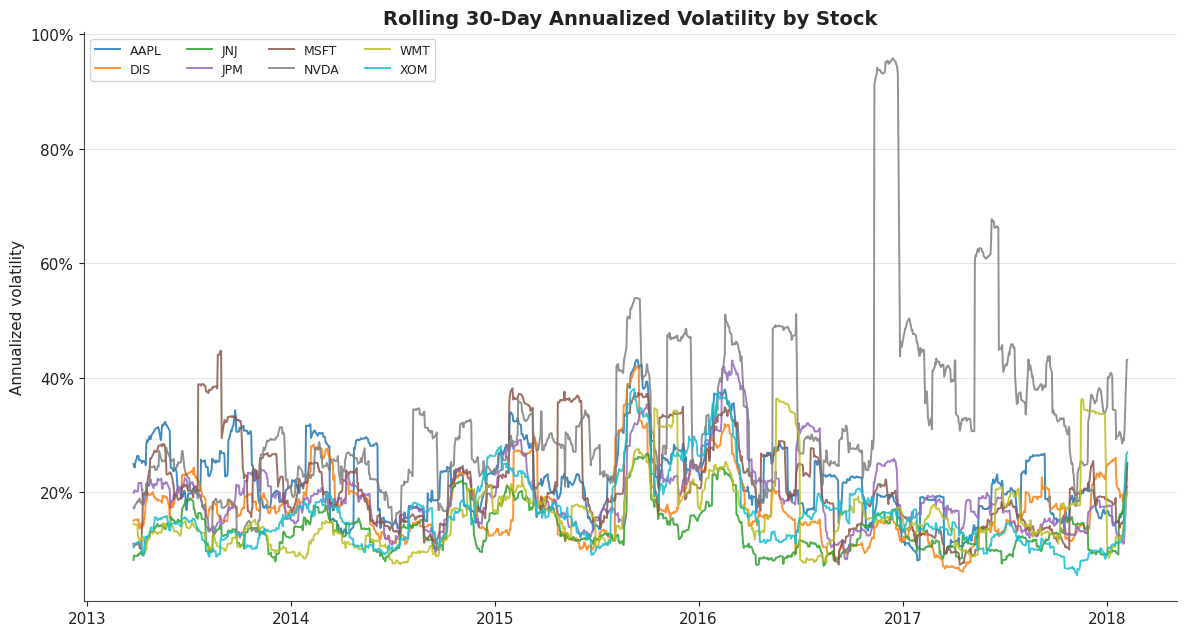

In [7]:
rolling_vol = returns.rolling(30).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(12, 6.5))
for i, t in enumerate(tickers):
    ax.plot(rolling_vol.index, rolling_vol[t], label=t, linewidth=1.4, color=colors[i], alpha=0.85)
ax.set_title("Rolling 30-Day Annualized Volatility by Stock")
ax.set_ylabel("Annualized volatility")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(ncol=4, fontsize=9)
ax.grid(axis="y")
plt.tight_layout()
plt.show()

## Correlation and Diversification

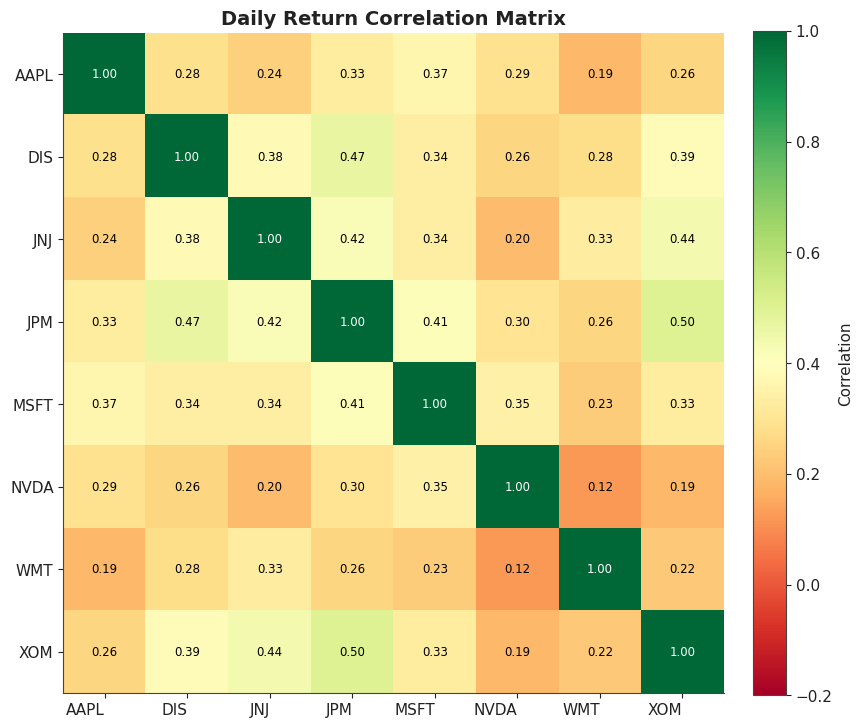

In [10]:
corr = returns.corr()

fig, ax = plt.subplots(figsize=(8.5, 7.5))
im = ax.imshow(corr.values, cmap="RdYlGn", vmin=-0.2, vmax=1)
ax.set_xticks(range(len(tickers))); ax.set_yticks(range(len(tickers)))
ax.set_xticklabels(tickers, rotation=0, ha="right")
ax.set_yticklabels(tickers)
ax.set_title("Daily Return Correlation Matrix")
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Correlation")
for i in range(len(tickers)):
    for j in range(len(tickers)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8.5,
                 color="white" if abs(corr.values[i, j]) > 0.6 else "black")
plt.tight_layout()
plt.show()

## Portfolio Construction vs. Benchmark

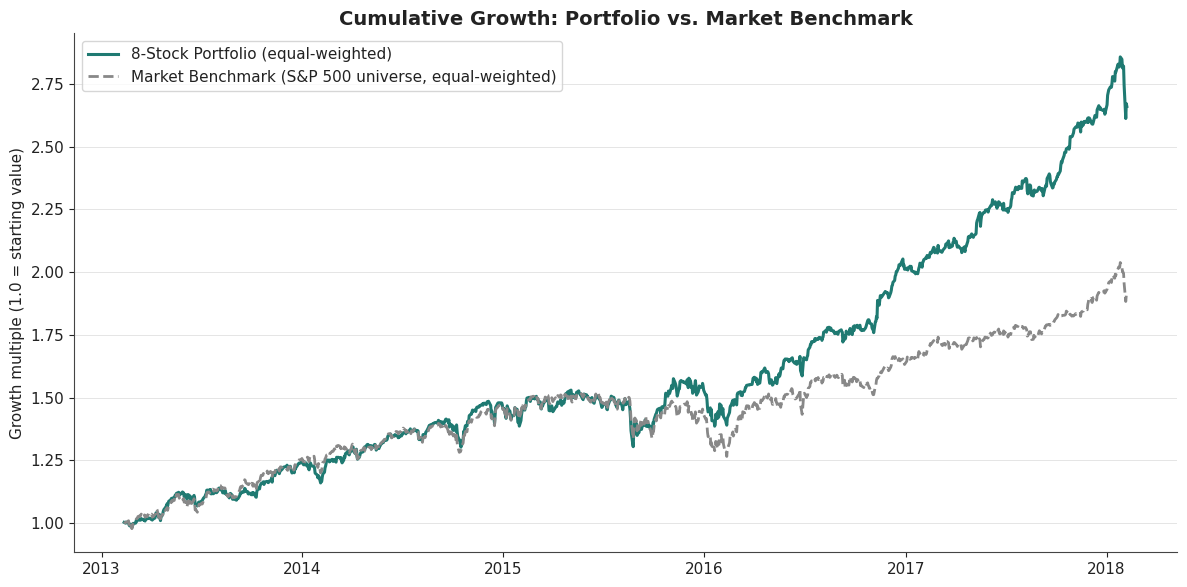

In [11]:
cum_portfolio = (1 + portfolio_returns).cumprod()
cum_benchmark = (1 + bench).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cum_portfolio.index, cum_portfolio.values, label="8-Stock Portfolio (equal-weighted)",
        color=TEAL, linewidth=2.2)
ax.plot(cum_benchmark.index, cum_benchmark.values, label="Market Benchmark (S&P 500 universe, equal-weighted)",
        color=GREY, linewidth=2, linestyle="--")
ax.set_title("Cumulative Growth: Portfolio vs. Market Benchmark")
ax.set_ylabel("Growth multiple (1.0 = starting value)")
ax.legend(loc="upper left")
ax.grid(axis="y")
plt.tight_layout()
plt.show()

## Risk Metrics

In [14]:
def annualize_return(daily_rets):
    return (1 + daily_rets.mean()) ** 252 - 1

def annualize_vol(daily_rets):
    return daily_rets.std() * np.sqrt(252)

def sharpe_ratio(daily_rets, rf=RISK_FREE_RATE):
    ann_ret = annualize_return(daily_rets)
    ann_vol = annualize_vol(daily_rets)
    return (ann_ret - rf) / ann_vol if ann_vol > 0 else np.nan

def historical_var(daily_rets, conf=0.95):
    return np.percentile(daily_rets, (1 - conf) * 100)

def max_drawdown(daily_rets):
    cum = (1 + daily_rets).cumprod()
    running_max = cum.cummax()
    dd = (cum - running_max) / running_max
    return dd.min()

def beta(daily_rets, bench_rets):
    aligned = pd.concat([daily_rets, bench_rets], axis=1).dropna()
    cov = aligned.iloc[:, 0].cov(aligned.iloc[:, 1])
    var = aligned.iloc[:, 1].var()
    return cov / var if var > 0 else np.nan

rows = []
for t in tickers:
    r = returns[t]
    rows.append({
        "Ticker": t, "Sector": sector_map[t],
        "AnnualizedReturn": annualize_return(r),
        "AnnualizedVolatility": annualize_vol(r),
        "SharpeRatio": sharpe_ratio(r),
        "VaR_95_Daily": historical_var(r),
        "MaxDrawdown": max_drawdown(r),
        "Beta": beta(r, bench),
    })
rows.append({"Ticker": "PORTFOLIO", "Sector": "All (Equal-Weighted)",
    "AnnualizedReturn": annualize_return(portfolio_returns), "AnnualizedVolatility": annualize_vol(portfolio_returns),
    "SharpeRatio": sharpe_ratio(portfolio_returns), "VaR_95_Daily": historical_var(portfolio_returns),
    "MaxDrawdown": max_drawdown(portfolio_returns), "Beta": beta(portfolio_returns, bench)})
rows.append({"Ticker": "BENCHMARK", "Sector": "Market (S&P 500 universe)",
    "AnnualizedReturn": annualize_return(bench), "AnnualizedVolatility": annualize_vol(bench),
    "SharpeRatio": sharpe_ratio(bench), "VaR_95_Daily": historical_var(bench),
    "MaxDrawdown": max_drawdown(bench), "Beta": 1.0})

risk_metrics = pd.DataFrame(rows)

## Risk vs. Return

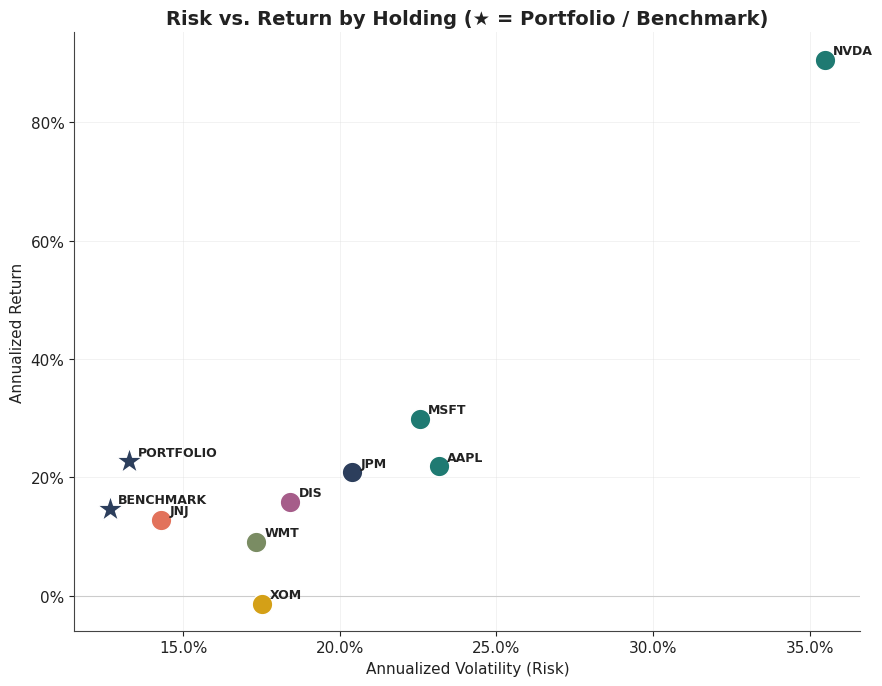

In [15]:
fig, ax = plt.subplots(figsize=(9, 7))
for _, row in risk_metrics.iterrows():
    color = SECTOR_COLORS.get(row["Sector"], NAVY)
    marker = "*" if row["Ticker"] in ("PORTFOLIO", "BENCHMARK") else "o"
    size = 400 if row["Ticker"] in ("PORTFOLIO", "BENCHMARK") else 220
    ax.scatter(row["AnnualizedVolatility"], row["AnnualizedReturn"], s=size, color=color,
               marker=marker, edgecolors="white", linewidth=1, zorder=5 if marker == "*" else 3)
    ax.annotate(row["Ticker"], (row["AnnualizedVolatility"], row["AnnualizedReturn"]),
                xytext=(6, 4), textcoords="offset points", fontsize=9, fontweight="bold")
ax.axhline(0, color="#cccccc", linewidth=0.8)
ax.set_xlabel("Annualized Volatility (Risk)")
ax.set_ylabel("Annualized Return")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title("Risk vs. Return by Holding (★ = Portfolio / Benchmark)")
ax.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

## Sharp Ratio Comparison

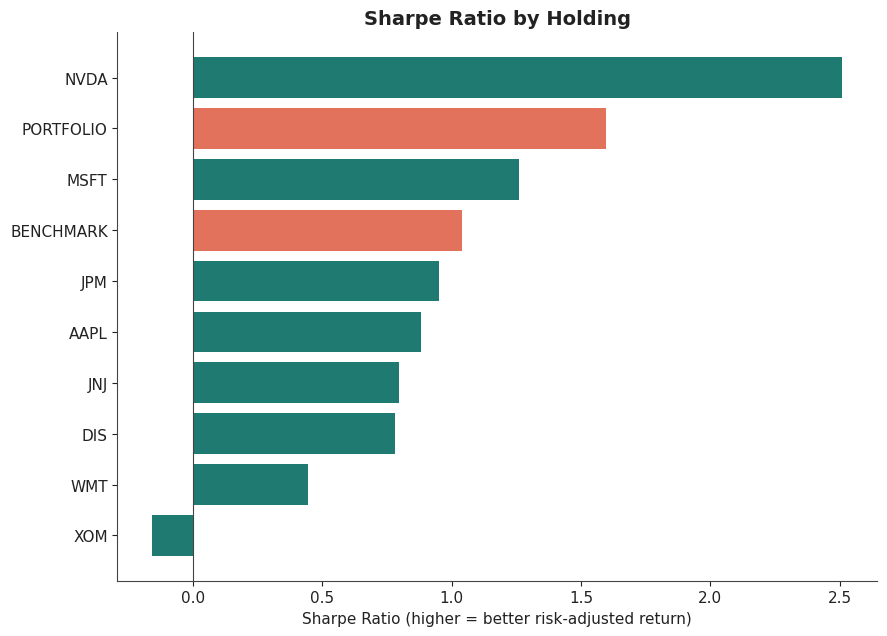

In [16]:
sharpe_sorted = risk_metrics.sort_values("SharpeRatio")
colors_bar = [CORAL if t in ("PORTFOLIO", "BENCHMARK") else TEAL for t in sharpe_sorted["Ticker"]]

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.barh(sharpe_sorted["Ticker"], sharpe_sorted["SharpeRatio"], color=colors_bar)
ax.set_title("Sharpe Ratio by Holding")
ax.set_xlabel("Sharpe Ratio (higher = better risk-adjusted return)")
ax.axvline(0, color="#444444", linewidth=0.8)
plt.tight_layout()
plt.show()

## Portfolio Drawdown

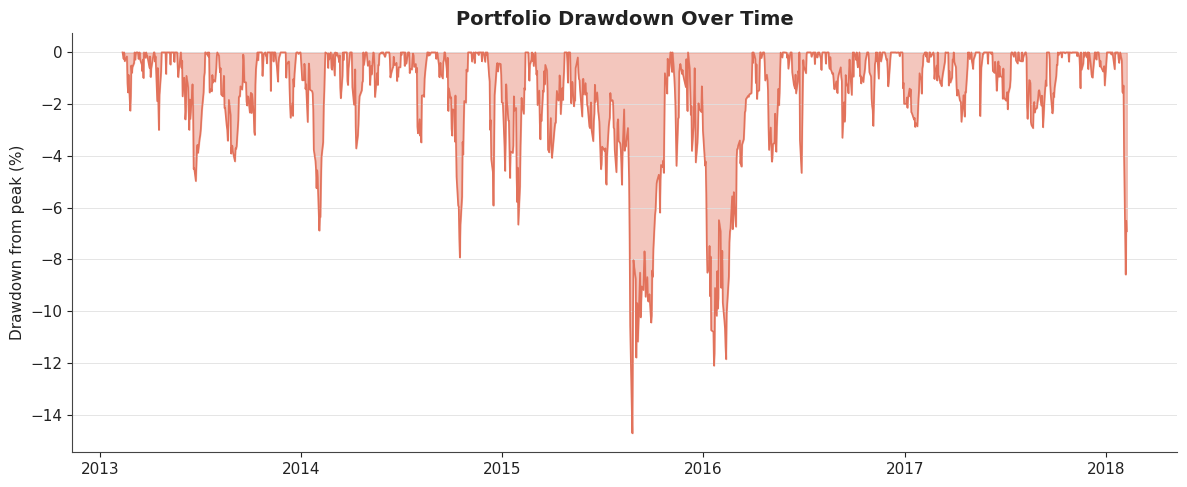

Portfolio max drawdown: -14.72%


In [17]:
cum = (1 + portfolio_returns).cumprod()
running_max = cum.cummax()
drawdown = (cum - running_max) / running_max

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(drawdown.index, drawdown.values * 100, 0, color=CORAL, alpha=0.4)
ax.plot(drawdown.index, drawdown.values * 100, color=CORAL, linewidth=1.2)
ax.set_title("Portfolio Drawdown Over Time")
ax.set_ylabel("Drawdown from peak (%)")
ax.grid(axis="y")
plt.tight_layout()
plt.show()

print(f"Portfolio max drawdown: {drawdown.min():.2%}")

Key Findings

**1. The portfolio beat the benchmark, and not by a small margin** - $1 invested in the 8-stock portfolio grew to roughly $2.6 over the 5 years vs ~$1.9 for the benchmark — a ~23% annualized return vs. ~15% for the market. The gap really opens up starting in 2016.

**2. That outperformance is almost entirely one stock: NVDA** - NVDA alone returned ~90% annualized (Sharpe ratio ~2.5) — $100 invested in NVDA alone grew to nearly $2,000. No other holding comes close. This is a concentration risk worth flagging: the portfolio's "outperformance" story is really an "NVDA" story, not a story about the stock-picking process across all 8 names.

3. **XOM (Energy) was a genuine drag** - XOM had a slightly negative annualized return and a negative Sharpe ratio (~‑0.15) — meaning it actually destroyed value on a risk-adjusted basis, the only holding to do so. $100 in XOM finished the period worth less than it started.

4. **Diversification was actually doing its job** - Pairwise correlations between holdings were all in a moderate-to-low range (0.12–0.50, no pair above 0.5). That's why portfolio volatility (~13%) came in lower than 6 of the 8 individual stocks — combining these names genuinely reduced risk rather than just averaging it.

5. **Risk was well controlled despite NVDA's volatility** - Max drawdown for the whole portfolio was ‑14.72% — fairly moderate, especially considering NVDA's ~36% annualized volatility on its own. Diversification absorbed a lot of that swing.

6. **Technical signals had some validity on AAPL** - A death cross in late 2015 preceded a price correction, and the golden cross in mid-2016 preceded a sustained rally from ~$100 to ~$180. It's one instance, so I'd call this suggestive rather than proof the signal "works."